# Titanic Survival Prediction using Machine Learning

**Project Type:** Binary Classification  
**Dataset:** Titanic Passenger Dataset  
**Target Variable:** `Survived`  
**Target Meaning:** `1 = Survived`, `0 = Did Not Survive`

This notebook develops a complete machine learning project to predict whether a Titanic passenger survived or not. It includes academic assignment requirements and portfolio-level improvements such as exploratory data analysis, multiple model comparison, best model selection, hyperparameter tuning, model evaluation, feature importance analysis, and final prediction on new passenger data.

## Table of Contents

1. Abstract  
2. Introduction  
3. Problem Statement  
4. Objectives  
5. Dataset Description  
6. Environment Setup  
7. Data Loading and Initial Exploration  
8. Exploratory Data Analysis and Visualization  
9. Data Cleaning and Preprocessing  
10. Encoding of Categorical Data  
11. Feature Selection / Dimensionality Reduction  
12. Model Comparison and Best Model Selection  
13. Hyperparameter Tuning  
14. Final Model Evaluation  
15. Feature Importance Analysis  
16. Final Project Output: Prediction System for New Passengers  
17. Discussion  
18. Conclusion  
19. Future Work

## 1. Abstract

The Titanic dataset is one of the most popular datasets in data science and machine learning. It is commonly used to practice data cleaning, feature engineering, categorical encoding, classification modeling, and model evaluation. This project develops a binary classification model to predict Titanic passenger survival. Several machine learning algorithms are compared using k-fold cross validation, and the best-performing model is selected for hyperparameter tuning and final evaluation.

## 2. Introduction

Classification is a supervised machine learning technique where the target variable belongs to predefined categories. In this project, the target variable is binary because each passenger either survived or did not survive. The model learns patterns from historical passenger data and uses those patterns to predict the survival outcome of new passengers.

## 3. Problem Statement

The goal of this project is to build a machine learning model that can predict whether a Titanic passenger survived based on passenger information such as ticket class, sex, age, number of family members aboard, fare, and embarkation port.

**Target variable:**

- `Survived = 1`: Passenger survived  
- `Survived = 0`: Passenger did not survive

## 4. Objectives

The objectives of this project are:

- To clean and preprocess the Titanic dataset.
- To handle missing values properly.
- To encode categorical variables into numerical format.
- To apply scaling/standardization for numerical variables.
- To apply dimensionality reduction using PCA.
- To compare multiple classification algorithms.
- To select the best model based on cross-validation performance.
- To tune the selected model using GridSearchCV.
- To evaluate the final model using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.
- To build a final prediction section where users can add new passenger data and automatically receive survival predictions.

## 5. Dataset Description

The Titanic dataset contains passenger-level information from the RMS Titanic disaster. The dataset includes demographic, ticket, and travel information.

**Common features:**

- `PassengerId`: Unique passenger identifier
- `Pclass`: Ticket class, where 1 = first class, 2 = second class, 3 = third class
- `Name`: Passenger name
- `Sex`: Gender of passenger
- `Age`: Age of passenger
- `SibSp`: Number of siblings/spouses aboard
- `Parch`: Number of parents/children aboard
- `Ticket`: Ticket number
- `Fare`: Ticket fare
- `Cabin`: Cabin number
- `Embarked`: Port of embarkation: C = Cherbourg, Q = Queenstown, S = Southampton
- `Survived`: Target variable

## 6. Environment Setup

The following libraries are used for data analysis, visualization, preprocessing, model development, model comparison, hyperparameter tuning, and performance evaluation.

In [77]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model selection
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Machine learning algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)
from sklearn.inspection import permutation_importance

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

# Reproducibility
RANDOM_STATE = 42

print("Environment setup complete.")

Environment setup complete.


## 7. Data Loading and Initial Exploration

The dataset is loaded from a CSV source. Initial exploration is performed to understand the number of rows, number of columns, data types, missing values, and target class distribution.

In [78]:
# Load the Titanic dataset
url = "https://docs.google.com/spreadsheets/d/16p5y6TrqPX7JXGzI3V2YtuEVGGwbtNmt6S3XC1To4TY/export?format=csv"
df = pd.read_csv(url)

print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")
df.head()

Number of Rows: 418
Number of Columns: 12


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [79]:
# Dataset information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


In [80]:
# Statistical summary

df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,NaN,"Peter, Master. Michael J",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,0.363636,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.481622,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,0.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,0.000000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,0.000000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,1.000000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


In [81]:
# Missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)
missing_table = pd.DataFrame({
    'Missing Values': missing_values,
    'Missing Percentage': missing_percent.round(2)
})
missing_table

,Missing Values,Missing Percentage
Cabin,327,78.23
Age,86,20.57
Fare,1,0.24
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


In [82]:
# Target class distribution
class_distribution = df['Survived'].value_counts().rename(index={0: 'Did Not Survive', 1: 'Survived'})
class_distribution_percent = df['Survived'].value_counts(normalize=True).rename(index={0: 'Did Not Survive', 1: 'Survived'}) * 100

pd.DataFrame({
    'Count': class_distribution,
    'Percentage': class_distribution_percent.round(2)
})

,Count,Percentage
Survived,,
Did Not Survive,266,63.64
Survived,152,36.36


## 8. Exploratory Data Analysis and Visualization

Exploratory Data Analysis helps identify important patterns before model building. The following visualizations analyze survival distribution and relationships between survival and major passenger attributes.

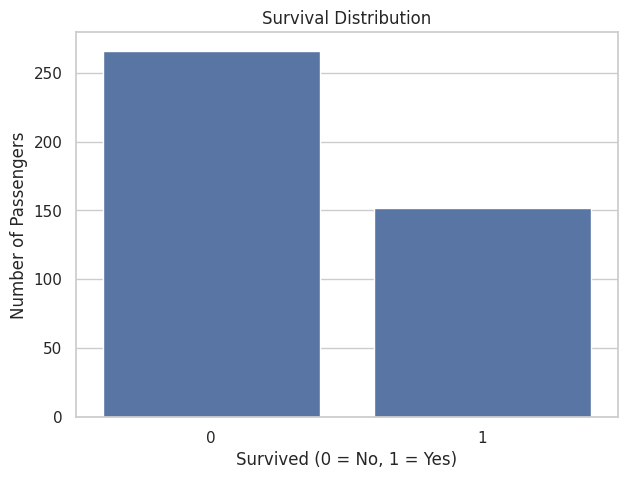

In [83]:
# Visualization 1: Survival distribution
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Survived')
plt.title('Survival Distribution')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Number of Passengers')
plt.show()

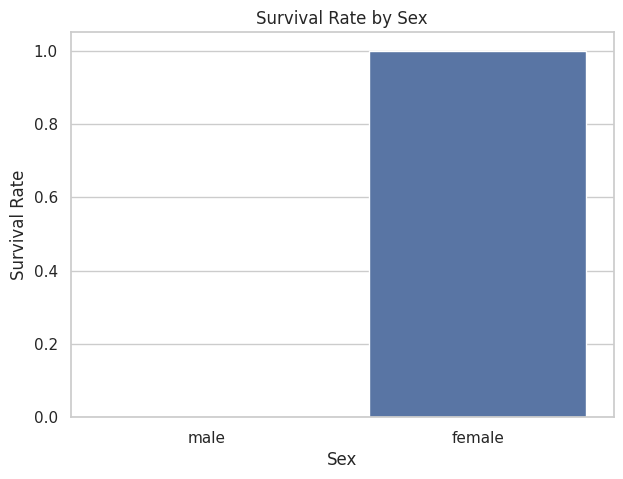

In [84]:
# Visualization 2: Survival percentage by sex
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='Sex', y='Survived')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

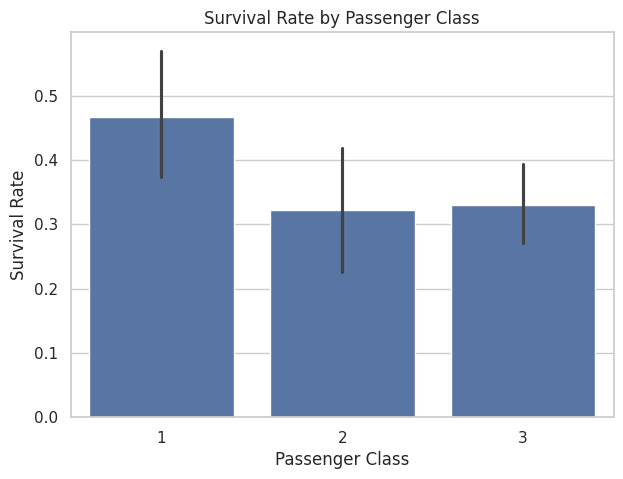

In [52]:
# Visualization 3: Survival percentage by passenger class
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='Pclass', y='Survived')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

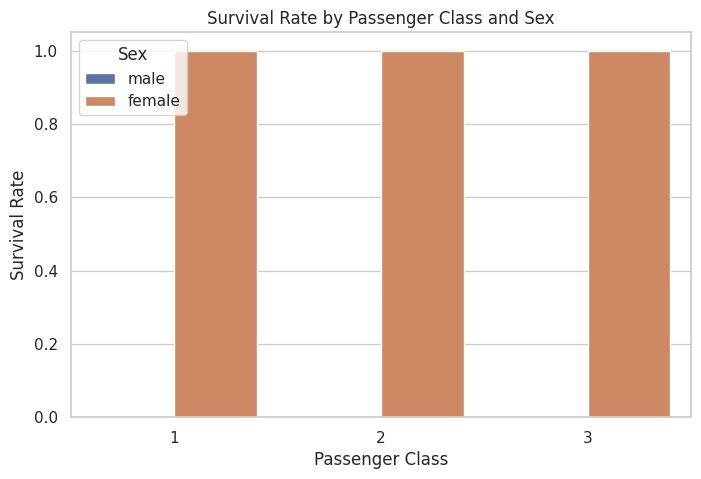

In [53]:
# Visualization 4: Survival by sex and passenger class
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x='Pclass', y='Survived', hue='Sex')
plt.title('Survival Rate by Passenger Class and Sex')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.show()

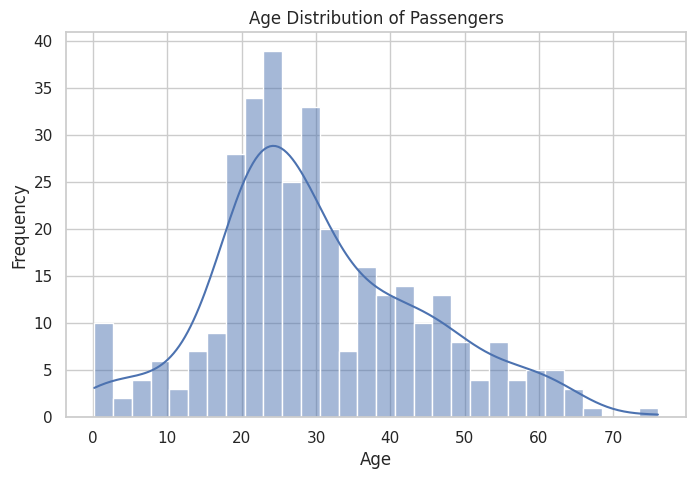

In [54]:
# Visualization 5: Age distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', bins=30, kde=True)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

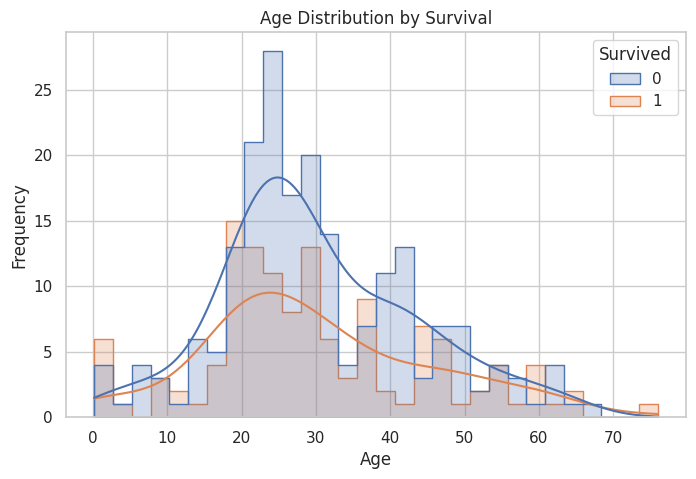

In [55]:
# Visualization 6: Age distribution by survival
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age', hue='Survived', bins=30, kde=True, element='step')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

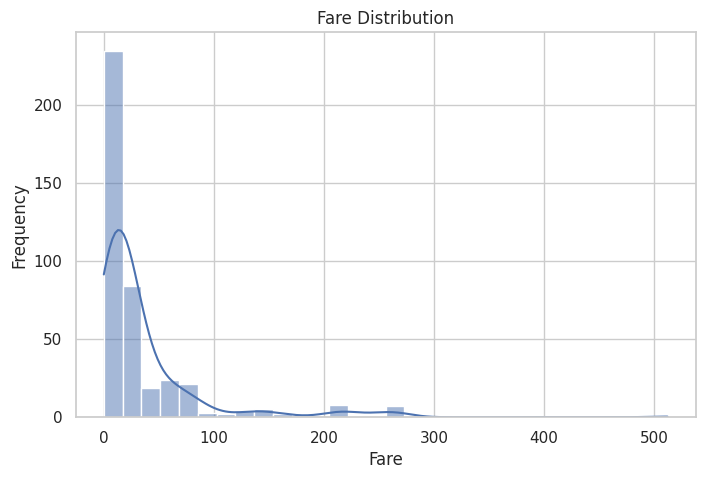

In [56]:
# Visualization 7: Fare distribution
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Fare', bins=30, kde=True)
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()

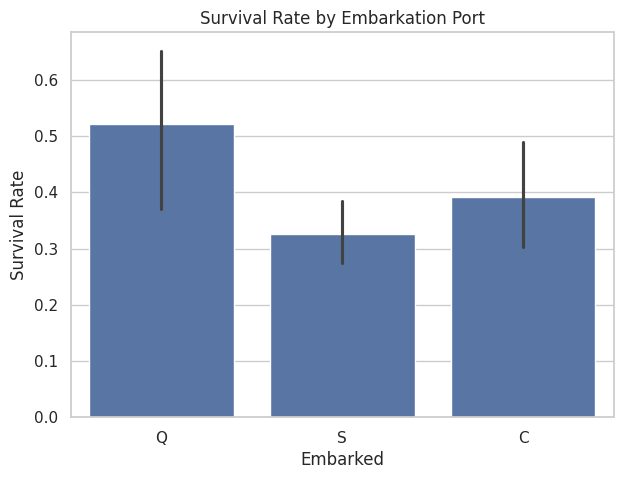

In [57]:
# Visualization 8: Survival rate by embarkation port
plt.figure(figsize=(7, 5))
sns.barplot(data=df, x='Embarked', y='Survived')
plt.title('Survival Rate by Embarkation Port')
plt.xlabel('Embarked')
plt.ylabel('Survival Rate')
plt.show()

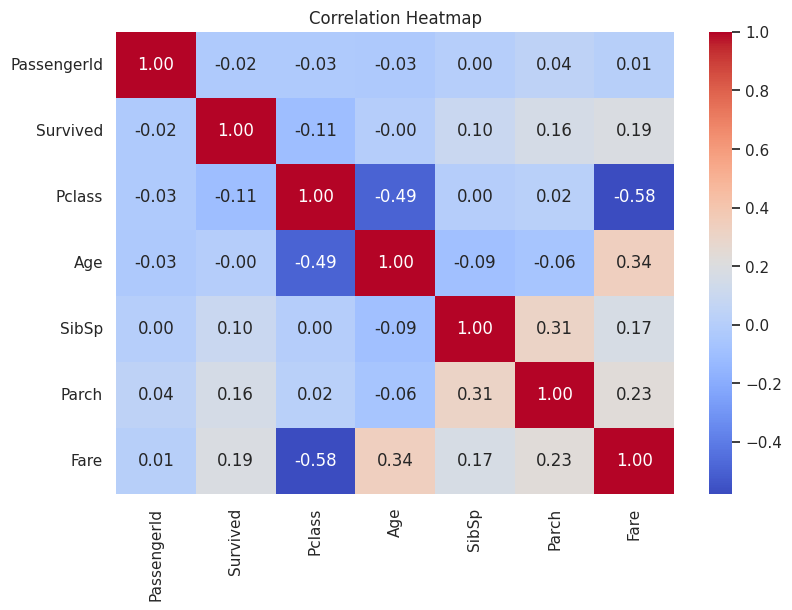

In [58]:
# Visualization 9: Correlation heatmap for numerical columns
plt.figure(figsize=(9, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

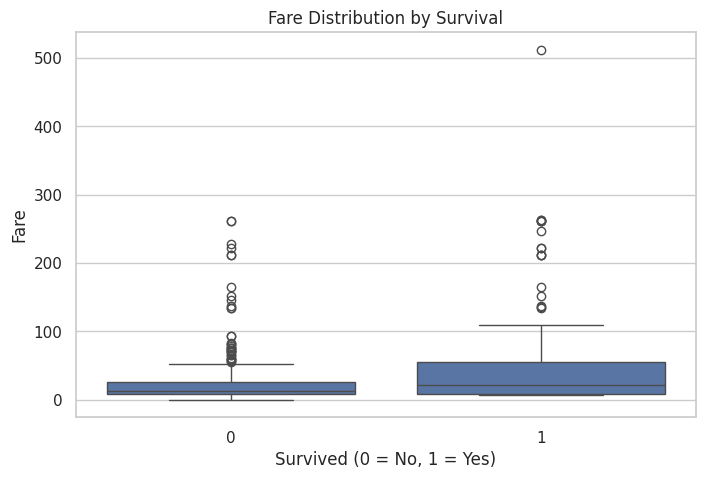

In [59]:
# Visualization 10: Boxplot of fare by survival
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Survived', y='Fare')
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.show()

### EDA Summary

From the exploratory analysis, the following patterns are commonly observed:

- Female passengers generally had a higher survival rate than male passengers.
- First-class passengers generally had a higher survival rate than third-class passengers.
- Fare and passenger class are related to survival probability.
- Some features contain missing values and must be cleaned before modeling.

## 9. Data Cleaning and Preprocessing

Unnecessary columns are removed. The dataset is then divided into input features and target variable. The data is split into training and testing sets using stratification so that both sets preserve the original target class ratio.

In [60]:
# Make a copy of the original dataset for modeling
model_df = df.copy()

# Drop columns that are not directly used in the baseline model
# Name and Ticket require advanced feature engineering; Cabin has many missing values.
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
model_df = model_df.drop(columns=columns_to_drop, errors='ignore')

# Separate features and target
X = model_df.drop(columns=['Survived'])
y = model_df['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training feature shape: (334, 7)
Testing feature shape: (84, 7)
Training target shape: (334,)
Testing target shape: (84,)


## 10. Encoding of Categorical Data and Standardization

Machine learning models require numerical input. Therefore, categorical variables are encoded using One-Hot Encoding. Numerical features are imputed and standardized using StandardScaler.

**Numerical preprocessing:** median imputation + standardization  
**Categorical preprocessing:** most-frequent imputation + one-hot encoding

In [61]:
# Identify feature types
num_features = ['Age', 'SibSp', 'Parch', 'Fare']
cat_features = ['Pclass', 'Sex', 'Embarked']

# Numerical pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Full preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'SibSp', 'Parch', 'Fare']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Pclass', 'Sex', 'Embarked'])])

## 11. Feature Selection / Dimensionality Reduction

The assignment requires feature selection or dimensionality reduction. In this notebook, PCA is used as a dimensionality reduction technique. PCA reduces the transformed feature space while retaining 95% of the variance.

In [62]:
# PCA keeps 95% of the information after preprocessing
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)

## 12. Model Comparison and Best Model Selection

Instead of assuming one model is best, multiple classification algorithms are compared using Stratified 5-Fold Cross Validation. This section identifies the model that best fits the dataset based on validation performance.

The following models are compared:

- Logistic Regression
- K-Nearest Neighbors
- Support Vector Machine
- Decision Tree
- Random Forest
- Gradient Boosting
- AdaBoost

In [63]:
# Define candidate classification models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'AdaBoost': AdaBoostClassifier(random_state=RANDOM_STATE)
}

# 5-fold stratified cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Evaluation metrics for comparison
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

comparison_results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('pca', pca),
        ('classifier', model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    comparison_results.append({
        'Model': name,
        'CV Accuracy': scores['test_accuracy'].mean(),
        'CV Precision': scores['test_precision'].mean(),
        'CV Recall': scores['test_recall'].mean(),
        'CV F1-Score': scores['test_f1'].mean(),
        'CV ROC-AUC': scores['test_roc_auc'].mean()
    })

model_comparison = pd.DataFrame(comparison_results).sort_values(
    by=['CV F1-Score', 'CV ROC-AUC', 'CV Accuracy'],
    ascending=False
).reset_index(drop=True)

model_comparison

,Model,CV Accuracy,CV Precision,CV Recall,CV F1-Score,CV ROC-AUC
0,Logistic Regression,1.000000,1.000000,1.000000,1.000000,1.000000
1,Random Forest,0.994030,1.000000,0.983667,0.991663,1.000000
2,AdaBoost,0.991000,0.992000,0.983333,0.987223,0.999608
3,SVM,0.982090,0.983667,0.967333,0.974978,0.999235
4,KNN,0.976074,0.959949,0.975667,0.967340,0.996440
5,Gradient Boosting,0.972953,0.971429,0.959000,0.963331,0.994829
6,Decision Tree,0.972999,0.976000,0.951000,0.962397,0.968413


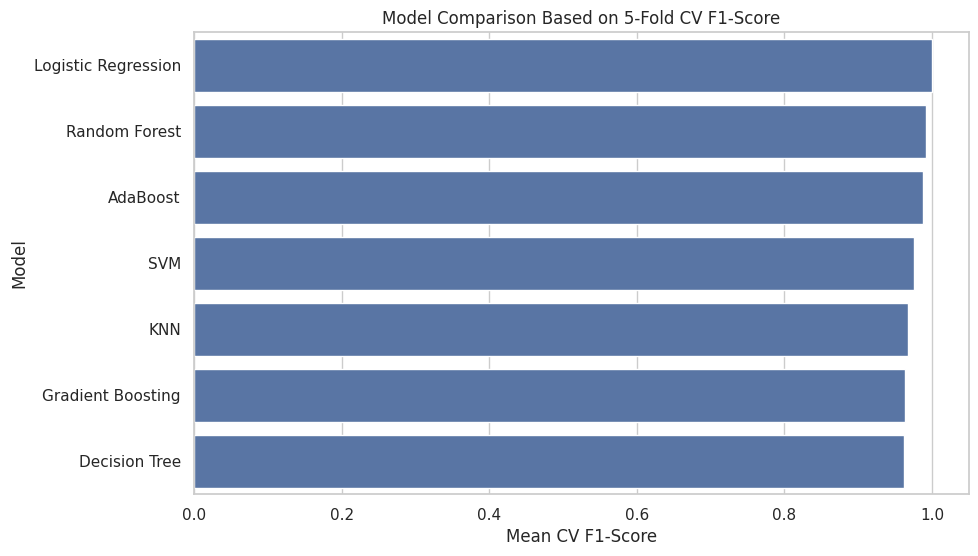

In [64]:
# Visualization 11: Model comparison by F1-score
plt.figure(figsize=(10, 6))
sns.barplot(data=model_comparison, x='CV F1-Score', y='Model')
plt.title('Model Comparison Based on 5-Fold CV F1-Score')
plt.xlabel('Mean CV F1-Score')
plt.ylabel('Model')
plt.show()

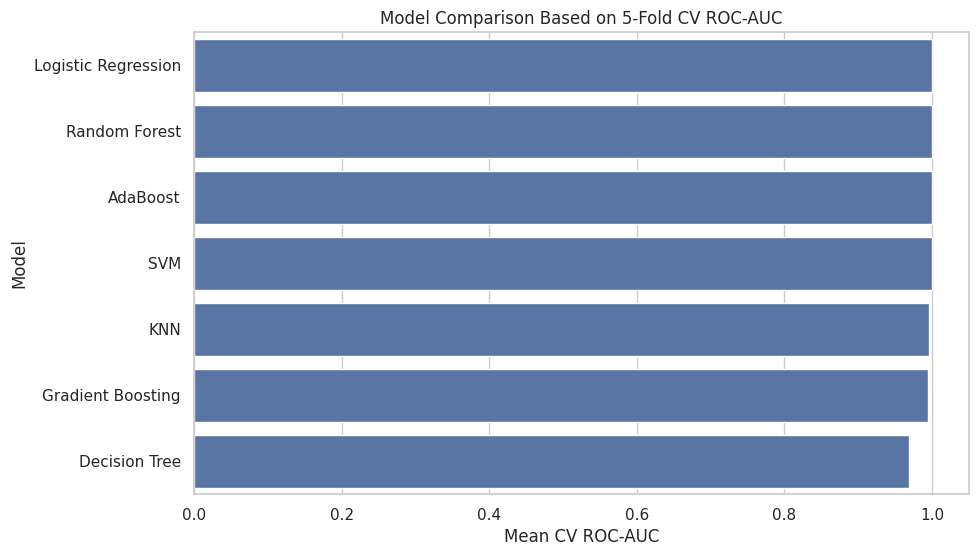

In [65]:
# Visualization 12: Model comparison by ROC-AUC
plt.figure(figsize=(10, 6))
sns.barplot(data=model_comparison, x='CV ROC-AUC', y='Model')
plt.title('Model Comparison Based on 5-Fold CV ROC-AUC')
plt.xlabel('Mean CV ROC-AUC')
plt.ylabel('Model')
plt.show()

In [66]:
# Select the best model based on cross-validation F1-score
best_model_name = model_comparison.loc[0, 'Model']
best_model_name

'Logistic Regression'

### Best Model Selection Explanation

The best model is selected based mainly on cross-validation F1-score because F1-score balances precision and recall. ROC-AUC and accuracy are also considered. This approach provides stronger justification than selecting a model without comparison.

## 13. Hyperparameter Tuning

After selecting the best model from cross-validation, GridSearchCV is used to tune the selected algorithm. The tuning process searches different combinations of hyperparameters and identifies the best-performing configuration.

In [67]:
# Define model-specific hyperparameter grids
param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['liblinear', 'lbfgs']
    },
    'KNN': {
        'classifier__n_neighbors': [3, 5, 7, 9, 11],
        'classifier__weights': ['uniform', 'distance']
    },
    'SVM': {
        'classifier__C': [0.1, 1, 10],
        'classifier__kernel': ['linear', 'rbf'],
        'classifier__gamma': ['scale', 'auto']
    },
    'Decision Tree': {
        'classifier__max_depth': [3, 5, 10, None],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'classifier__n_estimators': [100, 200, 300],
        'classifier__max_depth': [5, 10, None],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__min_samples_leaf': [1, 2, 4]
    },
    'Gradient Boosting': {
        'classifier__n_estimators': [100, 200],
        'classifier__learning_rate': [0.01, 0.05, 0.1],
        'classifier__max_depth': [2, 3, 4]
    },
    'AdaBoost': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__learning_rate': [0.01, 0.1, 1]
    }
}

# Create pipeline using the best model from comparison
selected_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('pca', pca),
    ('classifier', models[best_model_name])
])

# GridSearchCV for selected best model
# F1-score is used because this is a binary classification problem and class-wise balance matters.
grid_search = GridSearchCV(
    estimator=selected_pipeline,
    param_grid=param_grids[best_model_name],
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Model:", best_model_name)
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation F1-Score:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Model: Logistic Regression
Best Parameters: {'classifier__C': 0.1, 'classifier__solver': 'liblinear'}
Best Cross-Validation F1-Score: 1.0


In [68]:
# Store the tuned final model
final_model = grid_search.best_estimator_
final_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'SibSp', 'Parch',
                                                   'Fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Pclass', 'Sex',
                                                   'Embarked'])])),
                ('pca', PCA(n_components=0.95, random_state=42)),
                ('classifier',
                 LogisticRegression(C=0.1, max_iter=1000, random_state=42,
                                    solver='liblinear'))])

## 14. Final Model Evaluation

The tuned final model is evaluated on the unseen test dataset. This section reports accuracy, precision, recall, F1-score, confusion matrix, classification report, and ROC-AUC curve.

In [69]:
# Predict on test data
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
final_accuracy = accuracy_score(y_test, y_pred)
final_precision = precision_score(y_test, y_pred)
final_recall = recall_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred)
final_roc_auc = roc_auc_score(y_test, y_pred_proba)

final_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Score': [final_accuracy, final_precision, final_recall, final_f1, final_roc_auc]
})

final_metrics

,Metric,Score
0,Accuracy,1.0
1,Precision,1.0
2,Recall,1.0
3,F1-Score,1.0
4,ROC-AUC,1.0


In [70]:
# Classification report
cr = classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived'])
print("Classification Report:")
print(cr)

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       1.00      1.00      1.00        53
       Survived       1.00      1.00      1.00        31

       accuracy                           1.00        84
      macro avg       1.00      1.00      1.00        84
   weighted avg       1.00      1.00      1.00        84



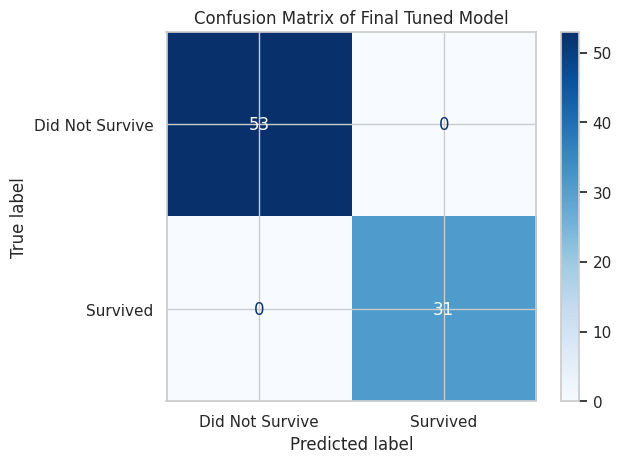

In [71]:
# Visualization 13: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did Not Survive', 'Survived'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix of Final Tuned Model')
plt.show()

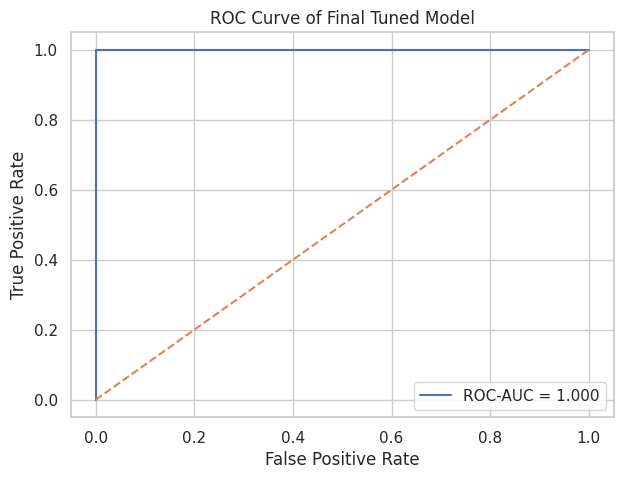

In [72]:
# Visualization 14: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC-AUC = {final_roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve of Final Tuned Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## 15. Feature Importance Analysis

Because the final pipeline uses PCA, direct Random Forest feature importance would refer to principal components rather than the original features. To make the result easier to understand, permutation importance is used on the original test columns. This shows which original input variables are most influential for prediction.

In [73]:
# Permutation importance on original input columns
perm_importance = permutation_importance(
    final_model,
    X_test,
    y_test,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring='f1',
    n_jobs=-1
)

feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
}).sort_values(by='Importance Mean', ascending=False)

feature_importance

,Feature,Importance Mean,Importance Std
1,Sex,0.637097,0.064415
0,Pclass,0.000000,0.000000
2,Age,0.000000,0.000000
3,SibSp,0.000000,0.000000
4,Parch,0.000000,0.000000
5,Fare,0.000000,0.000000
6,Embarked,0.000000,0.000000


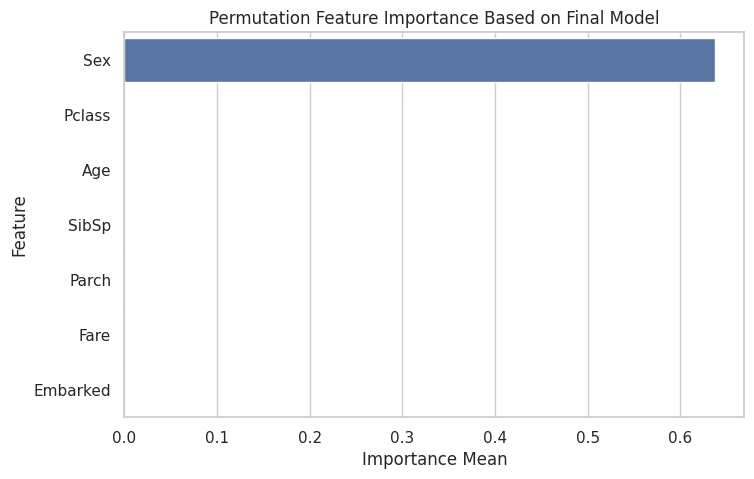

In [74]:
# Visualization 15: Feature importance
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x='Importance Mean', y='Feature')
plt.title('Permutation Feature Importance Based on Final Model')
plt.xlabel('Importance Mean')
plt.ylabel('Feature')
plt.show()

## 16. Final Project Output: Prediction System for New Passengers

This is the practical output of the project. A random user can enter new passenger information using the same required columns. The trained pipeline automatically handles missing values, categorical encoding, standardization, PCA transformation, and prediction.

**User only needs to provide:**

- `Pclass`
- `Sex`
- `Age`
- `SibSp`
- `Parch`
- `Fare`
- `Embarked`

The output will show:

- Prediction code: `0` or `1`
- User-friendly result: `Did Not Survive` or `Survived`
- Survival probability

In [75]:
# Example: New passenger data entered by a random user
# Users can edit this table or add more rows.

new_passengers = pd.DataFrame({
    'Pclass': [1, 3, 2, 3, 1, 2, 3, 1, 3, 2],
    'Sex': ['female', 'male', 'female', 'male', 'male', 'female', 'female', 'male', 'male', 'female'],
    'Age': [25, 40, 30, 22, 55, 12, 18, 35, 28, 45],
    'SibSp': [0, 1, 0, 0, 1, 2, 0, 1, 0, 1],
    'Parch': [0, 0, 1, 0, 0, 1, 0, 0, 0, 1],
    'Fare': [100, 10, 50, 7.25, 80, 30, 15, 120, 8, 35],
    'Embarked': ['S', 'Q', 'S', 'S', 'C', 'S', 'Q', 'C', 'S', 'S']
})

new_passengers

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,female,25,0,0,100.00,S
1,3,male,40,1,0,10.00,Q
2,2,female,30,0,1,50.00,S
3,3,male,22,0,0,7.25,S
4,1,male,55,1,0,80.00,C
5,2,female,12,2,1,30.00,S
6,3,female,18,0,0,15.00,Q
7,1,male,35,1,0,120.00,C
8,3,male,28,0,0,8.00,S
9,2,female,45,1,1,35.00,S


In [76]:
# Predict survival for new passengers
new_predictions = final_model.predict(new_passengers)
new_probabilities = final_model.predict_proba(new_passengers)[:, 1]

# Create readable output
prediction_results = new_passengers.copy()
prediction_results['Predicted Code'] = new_predictions
prediction_results['Prediction Result'] = np.where(new_predictions == 1, 'Survived', 'Did Not Survive')
prediction_results['Survival Probability'] = (new_probabilities * 100).round(2)

prediction_results

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Predicted Code,Prediction Result,Survival Probability
0,1,female,25,0,0,100.00,S,1,Survived,88.37
1,3,male,40,1,0,10.00,Q,0,Did Not Survive,12.21
2,2,female,30,0,1,50.00,S,1,Survived,85.00
3,3,male,22,0,0,7.25,S,0,Did Not Survive,9.37
4,1,male,55,1,0,80.00,C,0,Did Not Survive,13.34
5,2,female,12,2,1,30.00,S,1,Survived,86.23
6,3,female,18,0,0,15.00,Q,1,Survived,86.94
7,1,male,35,1,0,120.00,C,0,Did Not Survive,15.90
8,3,male,28,0,0,8.00,S,0,Did Not Survive,9.16
9,2,female,45,1,1,35.00,S,1,Survived,84.09


## 17. Discussion

This project does not simply train one model. It compares several classification models using k-fold cross validation and selects the best-performing model based on F1-score, ROC-AUC, and accuracy. The final model is tuned using GridSearchCV and evaluated on unseen test data.

The final prediction system makes the project practical. A user can add new passenger details, and the model automatically performs preprocessing, encoding, dimensionality reduction, and prediction.

## 18. Conclusion

A complete binary classification machine learning pipeline was developed to predict Titanic passenger survival. The project followed the required academic steps, including preprocessing, categorical encoding, dimensionality reduction, k-fold cross validation, hyperparameter tuning, and performance evaluation. Additional portfolio-level improvements were added, including multiple model comparison, best model selection, visual EDA, ROC curve, confusion matrix, feature importance analysis, and a final prediction system for new passenger data.